# Breast Cancer Dataset - Regularization

### [Breast Cancer Dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Wolberg, Street, and Mangasarian, https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy pandas matplotlib scikit-learn

## Import Libraries

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
%matplotlib inline

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
torch.manual_seed(SEED)

## Parameters

In [5]:
IN_FEATURES = 30
IN_FEATURES

30

In [6]:
H1 = 32
H1

32

In [7]:
H2 = 16
H2

16

In [8]:
OUT_FEATURES = 2
OUT_FEATURES

2

In [9]:
TEST_SIZE = 0.3
TEST_SIZE

0.3

## Hyperparameters

In [10]:
LEARNING_RATE = 0.001
LEARNING_RATE

0.001

In [11]:
EPOCHS = 300
EPOCHS

300

In [12]:
BATCH_SIZE = 32
BATCH_SIZE

32

In [13]:
DROPOUT = 0.3
DROPOUT

0.3

In [14]:
WEIGHT_DECAY = 0.01
WEIGHT_DECAY

0.01

In [15]:
PATIENCE = 20
PATIENCE

20

## Device

In [16]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Load Dataset

In [17]:
data = load_breast_cancer()
X = data.data.astype(np.float32)
y = data.target.astype(np.int64)
X.shape, y.shape

((569, 30), (569,))

## Clean Dataset

### Standardize the Features

In [18]:
X_MEAN = X.mean(axis=0)
X_STD = X.std(axis=0)
X = (X - X_MEAN) / X_STD
X.shape

(569, 30)

## Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
X_train.shape, X_test.shape

((398, 30), (171, 30))

## Create Dataset and DataLoaders

In [20]:
class NumpyDataset(torch.utils.data.Dataset):
    """
    A memory-efficient dataset that stores data as NumPy arrays.
    """

    def __init__(self, X, y, device):
        """
        Initialize the dataset with NumPy arrays.

        Parameters:
            X (np.ndarray): Feature array.
            y (np.ndarray): Label array.
            device (torch.device): Device to move tensors to.

        Returns:
            None
        """
        self.X = X
        self.y = y
        self.device = device

    def __len__(self):
        """
        Return the number of samples in the dataset.

        Parameters:
            None

        Returns:
            int: Number of samples.
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Return a single sample as tensors on the device.

        Parameters:
            idx (int): Index of the sample.

        Returns:
            tuple: Feature and label tensors.
        """
        X_tensor = torch.tensor(self.X[idx]).float().to(self.device)
        y_tensor = torch.tensor(self.y[idx]).long().to(self.device)
        return X_tensor, y_tensor

In [21]:
train_loader = DataLoader(NumpyDataset(X_train, y_train, DEVICE),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(NumpyDataset(X_test, y_test, DEVICE),
                         batch_size=BATCH_SIZE, shuffle=False)
len(train_loader), len(test_loader)

(13, 6)

## Create Model

Dropout randomly zeroes hidden units during training, which forces the network to avoid relying on any single unit.

In [22]:
class Model(nn.Module):
    """
    A regularized feedforward neural network with dropout.
    """

    def __init__(self, in_features=IN_FEATURES, h1=H1, h2=H2,
                 out_features=OUT_FEATURES, dropout=DROPOUT):
        """
        Initialize the neural network layers.

        Parameters:
            in_features (int): Number of input features.
            h1 (int): Neurons in the first hidden layer.
            h2 (int): Neurons in the second hidden layer.
            out_features (int): Number of output features.
            dropout (float): Dropout rate.

        Returns:
            None
        """
        super(Model, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(h2, out_features))

    def forward(self, x):
        """
        Run the forward pass of the network.

        Parameters:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output logits.
        """
        return self.net(x)

## Instantiate Model, Loss, and Optimizer

AdamW applies decoupled weight decay, which shrinks large weights and reduces overfitting.

In [23]:
torch.manual_seed(SEED)
model = Model().to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                              weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
model

Model(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=2, bias=True)
  )
)

## Train Model

### Functions

In [24]:
def train_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model for a single epoch.

    Parameters:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        loss_fn (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


def evaluate(model, loader, loss_fn):
    """
    Evaluate the model over a loader.

    Parameters:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Evaluation data loader.
        loss_fn (nn.Module): Loss function.

    Returns:
        tuple: Mean loss and accuracy.
    """
    model.eval()
    total, correct = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            total += loss_fn(logits, y).item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total / n, correct / n

### Early Stopping

Early stopping halts training when validation loss stops improving. The best weights are restored at the end.

In [25]:
best_loss = float('inf')
best_state = None
wait = 0
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    val_loss, val_accuracy = evaluate(model, test_loader, loss_fn)
    scheduler.step()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if val_loss < best_loss:
        best_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stop at epoch {epoch + 1}")
            break
model.load_state_dict(best_state)
print(f"Best validation loss: {best_loss:.4f}")

Early stop at epoch 48
Best validation loss: 0.0710


### Visualize Training

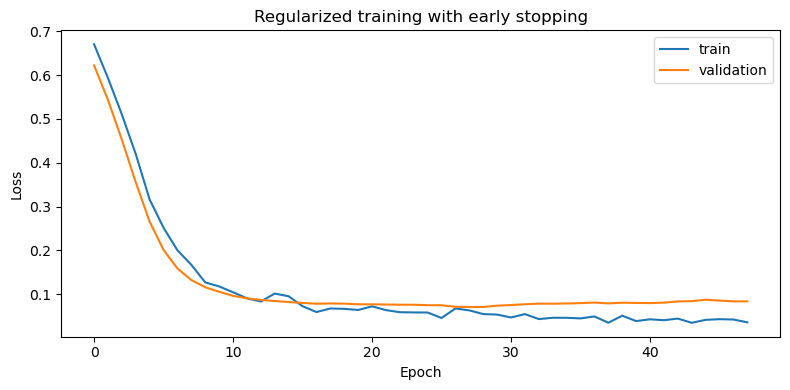

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Regularized training with early stopping')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluate Model

In [27]:
_, accuracy = evaluate(model, test_loader, loss_fn)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9649


## Save Model

In [28]:
torch.save(model.state_dict(), 'reg_breast_cancer.pt')
print('saved reg_breast_cancer.pt')

saved reg_breast_cancer.pt


## Load Model

In [29]:
loaded_model = Model().to(DEVICE)
loaded_model.load_state_dict(torch.load('reg_breast_cancer.pt', map_location=DEVICE))
loaded_model.eval()
print('loaded reg_breast_cancer.pt')

loaded reg_breast_cancer.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_55256/640927886.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('reg_b

## Inference

### Function

In [30]:
def predict(model, features):
    """
    Predict benign or malignant for one raw feature vector.

    Parameters:
        model (nn.Module): Trained model.
        features (list): Raw feature values.

    Returns:
        tuple: Predicted label name and confidence.
    """
    model.eval()
    scaled = (np.array(features, dtype=np.float32) - X_MEAN) / X_STD
    with torch.no_grad():
        X_new = torch.tensor(scaled).float().to(DEVICE).unsqueeze(0)
        probs = torch.softmax(model(X_new), dim=1)
        confidence, predicted = probs.max(dim=1)
    names = ['malignant', 'benign']
    return names[predicted.item()], confidence.item()

### Run Inference

In [31]:
label, confidence = predict(loaded_model, X_test[0])
print(f"Predicted: {label} ({confidence:.4f}) | Actual: {data.target_names[y_test[0]]}")

Predicted: benign (1.0000) | Actual: malignant
